# Arrival model tuning charts (sketch)

Curated matplotlib prototypes for the PR #78 arrival **settings pane**: five slider ↔ chart pairs with inline outputs. Built on `worktree-T-163-corridor-mixture`.

**Data:** PyO3 `arrival_marginal_cdf_py` for filter laws; `arrival_tuning_sketch_data` Rust example for traces and Var(log Λ) MC.


In [1]:
from __future__ import annotations

import json
import subprocess
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

REPO = Path.cwd().resolve()
if not (REPO / "src" / "blueberries_voi").is_dir():
    REPO = REPO.parent
assert (REPO / "data" / "abdella" / "arrival_model.json").is_file(), REPO

SCRATCH = Path(tempfile.gettempdir()) / "blueberries-voi-arrival-sketch"
SCRATCH.mkdir(parents=True, exist_ok=True)

ARTIFACT = REPO / "data" / "abdella" / "arrival_model.json"
BASE_ARTIFACT = json.loads(ARTIFACT.read_text())

from blueberries_voi._core import arrival_marginal_cdf_py


def write_artifact(overrides: dict) -> str:
    art = {**BASE_ARTIFACT, **overrides}
    path = SCRATCH / "_tmp_arrival_model.json"
    path.write_text(json.dumps(art))
    return str(path)


def cdf_to_pdf(cdf: np.ndarray, f: np.ndarray) -> np.ndarray:
    return np.clip(np.gradient(cdf, f), 0.0, None)


def marginal_pdf(
    condition: str,
    *,
    overrides: dict | None = None,
    n: int = 256,
) -> tuple[np.ndarray, np.ndarray, float]:
    src = write_artifact(overrides or {})
    f = np.linspace(0.0, 1.0, n)
    cdf = np.asarray(arrival_marginal_cdf_py(src, condition, f.tolist()), dtype=float)
    return f, cdf_to_pdf(cdf, f), float(cdf[0])


def cargo_sketch_data() -> dict:
    cmd = [
        "cargo", "run", "-p", "voi_core", "--release",
        "--example", "arrival_tuning_sketch_data",
    ]
    t0 = time.perf_counter()
    proc = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True, check=True)
    print(f"arrival_tuning_sketch_data: {time.perf_counter() - t0:.1f}s")
    return json.loads(proc.stdout)


SKETCH = cargo_sketch_data()
PHI_SET = float(SKETCH["phi_set"])


arrival_tuning_sketch_data: 105.4s


## Chart 1 — Preview transit days → P(f | d) vs Prior

**Context.** Every delivery arrives already partway through its shelf life: transit duration and cold-chain exposure have degraded the lot before it hits the shelf. Before any observation, the particle filter holds an unconditional **Prior** over arrival freshness **f** ∈ [0, 1]. A pack date on the delivery ASN is, in effect, a measurement of calendar transit duration **d**; the filter then conditions on `Duration(d)`, which collapses most shipment-level uncertainty because duration still dominates exposure variance on the Abdella-matched corridor (especially at low break rates).

**Function.** This chart overlays the unconditional Prior PDF against `Duration(d)` laws for preview days **d** ∈ {2, …, 7}. In the studio, a `preview_transit_days` slider would highlight one conditional curve while the dashed Prior stays fixed — illustrating why the pack-date channel (F2a/F2) is the largest single step on the knowledge ladder. Laws are the same `rung_law_on_grid` integration the filter uses (`arrival_marginal_cdf_py`).

| Symbol | Meaning |
|--------|---------|
| **f** | Unit freshness at receipt (1 = pristine, 0 = spoiled) |
| **d** | Calendar transit duration (days); per-delivery draw from Abdella shifted-gamma corridor |
| **Prior** | Unconditional arrival law (`ArrivalCondition::Prior`) before delivery observations |
| **Duration(d)** | Filter law after pack-date channel pins **d** (`ArrivalCondition::Duration(d)`) |


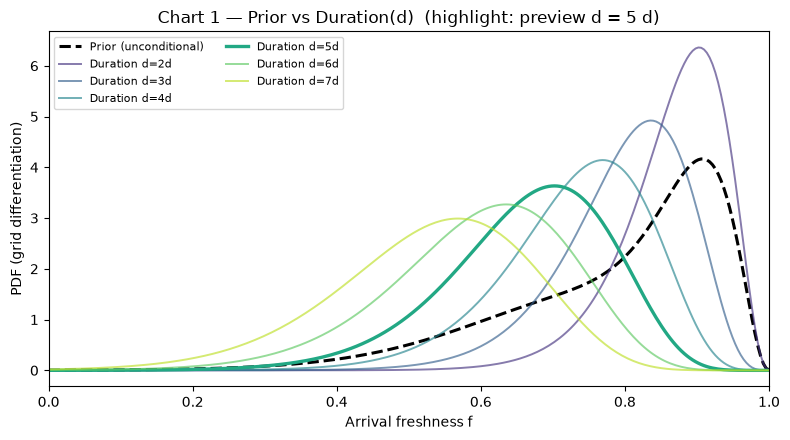

In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))
preview_days = np.arange(2, 8)

f, pdf_prior, _ = marginal_pdf("prior")
ax.plot(f, pdf_prior, color="black", lw=2.2, ls="--", label="Prior (unconditional)")

colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(preview_days)))
highlight_d = 5
for d, c in zip(preview_days, colors, strict=True):
    f_d, pdf_d, _ = marginal_pdf(f"duration:{d}")
    lw = 2.4 if d == highlight_d else 1.4
    alpha = 1.0 if d == highlight_d else 0.65
    ax.plot(f_d, pdf_d, color=c, lw=lw, alpha=alpha, label=f"Duration d={d}d")

ax.set_xlabel("Arrival freshness f")
ax.set_ylabel("PDF (grid differentiation)")
ax.set_title("Chart 1 — Prior vs Duration(d)  (highlight: preview d = 5 d)")
ax.set_xlim(0, 1)
ax.legend(ncol=2, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()


## Chart 2 — Mean break duration τ̄ → synthetic break trace

**Context.** Cold-chain damage concentrates at handoffs — dock time, missed connections, reefer doors open — not in “the truck ran slightly warm.” Under ADR 0150, a **break** is a discrete episode at fixed temperature **T_break** lasting **τ** ~ Exp(τ̄), drawn **inside** calendar trip duration **d** (breaks do not extend **d**). Cumulative exposure is Λ = **d**·φ_set + Σ_j τ_j·(φ_break − φ_set), where φ_set is the duration-weighted baseline exposure rate and φ_break = φ(**T_break**) under the Q10 law.

**Function.** This chart plots `truth_transit_trace` for a representative haul (**d** ≈ 5.5 d) at fixed break hazard **ρ**, sweeping mean break duration **τ̄** ∈ {0.1, 0.5, 1.0, 1.5} d. Wider pulses integrate to larger Λ and widen the downstream arrival-f law even when **ρ** is fixed — the studio slider teaches *duration severity* of a break, not ambient temperature noise.

| Symbol | Meaning |
|--------|---------|
| **τ̄** (`tau_bar`) | Mean break episode length (days); individual breaks ~ Exp(1/τ̄) |
| **T_break** | Fixed temperature during a break (°C); default 12 °C in artifact |
| **ρ** | Break hazard (episodes per transit-day); N ~ Poisson(ρ·**d**) |
| **φ_set**, **φ_break** | Exposure-rate multipliers at baseline legs vs break temperature |
| **Λ** | Cumulative thermal exposure (reference-days) integrated from the path |
| **d** | Total calendar transit time (days); trip clock runs during breaks |


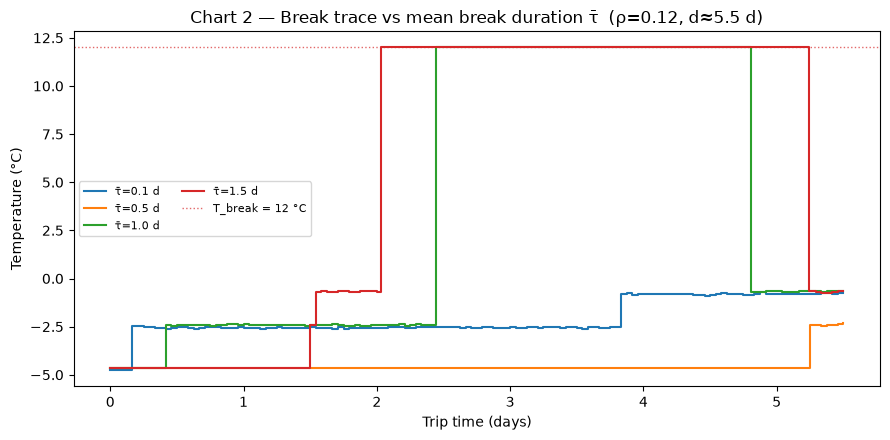

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for tr in SKETCH["tau_bar_traces"]:
    tb = tr["tau_bar"]
    ax.plot(tr["times_d"], tr["temps_c"], lw=1.5, label=f"τ̄={tb:.1f} d")
ax.axhline(12.0, color="C3", ls=":", lw=1, alpha=0.7, label="T_break = 12 °C")
ax.set_xlabel("Trip time (days)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Chart 2 — Break trace vs mean break duration τ̄  (ρ=0.12, d≈5.5 d)")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


## Chart 3 — Break hazard ρ → share of Var(log Λ)

**Context.** Pack date pins calendar duration **d**, removing most shipment-level uncertainty in log exposure. What remains for the temperature-history channel (F3) is thermal detail **inside** the trip — chiefly compound-Poisson **breaks**. At ρ → 0 the clean-chain path leaves duration (plus trip mode and hourly OU) as the only drivers; at default ρ ≈ 0.08/day the design target is roughly **80% duration / 20% break** share of Var(log Λ) (scenario assumption, not fit from six clean Abdella traces).

**Function.** Monte Carlo draws Λ from the generative model at each **ρ** on the grid and compares Var(log Λ) to the ρ = 0 baseline. The stacked bars show how much incremental log-variance breaks contribute as **ρ** rises — the studio knob that makes F3 worth more than the retired 1.6% “decorative trace” mop-up. Dashed lines mark the documented ~82% / ~18% design reference at default ρ.

| Symbol | Meaning |
|--------|---------|
| **ρ** | Break hazard rate (breaks per transit-day) |
| **Λ** | Per-delivery cumulative thermal exposure |
| **Var(log Λ)** | Log-variance of **Λ** across simulated trips |
| **duration_share** | Fraction of Var(log Λ) attributable to ρ = 0 path (duration + clean thermal) |
| **break_share** | Incremental fraction from break episodes at the shown **ρ** |


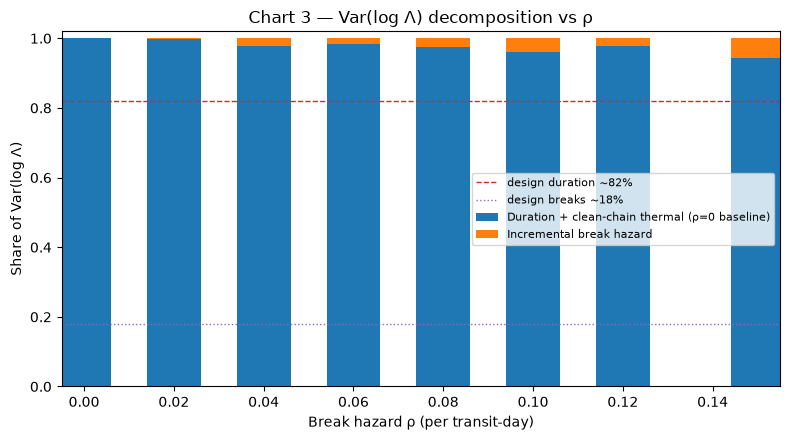

MC at ρ=0.08: [{'break_share': 0.0240849740948372, 'duration_share': 0.9759150259051628, 'rho': 0.08, 'var_log_lambda_clean': 0.18118414593199858, 'var_log_lambda_full': 0.1856556576367394}]


In [4]:
rows = sorted(SKETCH["var_log_decomposition"], key=lambda r: r["rho"])
rhos = [r["rho"] for r in rows]
dur = [r["duration_share"] for r in rows]
brk = [r["break_share"] for r in rows]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(rhos, dur, width=0.012, label="Duration + clean-chain thermal (ρ=0 baseline)")
ax.bar(rhos, brk, width=0.012, bottom=dur, label="Incremental break hazard")
ax.axhline(0.82, color="C3", ls="--", lw=1, label="design duration ~82%")
ax.axhline(0.18, color="C4", ls=":", lw=1, label="design breaks ~18%")
ax.set_xlabel("Break hazard ρ (per transit-day)")
ax.set_ylabel("Share of Var(log Λ)")
ax.set_title("Chart 3 — Var(log Λ) decomposition vs ρ")
ax.set_xlim(-0.005, 0.155)
ax.set_ylim(0, 1.02)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
print("MC at ρ=0.08:", [r for r in rows if abs(r["rho"] - 0.08) < 1e-9])


## Chart 4 — Position spread σ_pos → arrival freshness Prior

**Context.** Trip duration and temperature trace pin down **shared** lot exposure Λ_lot, but every unit also draws a private within-pallet multiplier **ψ** ~ LogNormal(0, σ_pos). Unit exposure is Λ_unit = Λ_lot · **ψ**, then freshness **f** is drawn from the same shape-scaled gamma law as in-store aging. No observation channel — not even F3 — reveals **ψ**, so units from one lot can legitimately differ in **f**.

**Function.** Sweeps σ_pos on the artifact and plots the unconditional Prior PDF plus the spoiled-on-arrival atom P(**f** = 0). This is the legitimate studio spread control (replacing legacy `spread_scale`): it widens belief without faking generative physics. Higher σ_pos increases tail mass toward low **f** while leaving mean Λ unchanged.

| Symbol | Meaning |
|--------|---------|
| **σ_pos** | Lognormal scale of within-pallet position multiplier **ψ** |
| **ψ** | Per-unit exposure multiplier (E[ψ] = 1) |
| **f** | Freshness at receipt after gamma draw given Λ_unit |
| **P(f = 0)** | Spoiled-on-arrival probability (CDF atom at 0) |


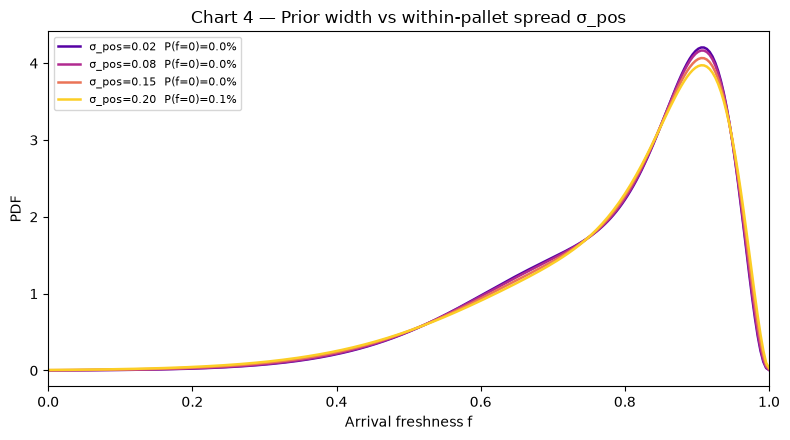

In [5]:
sigmas = [0.02, 0.08, 0.15, 0.20]
fig, ax = plt.subplots(figsize=(8, 4.5))
for sig, c in zip(sigmas, plt.cm.plasma(np.linspace(0.15, 0.9, len(sigmas))), strict=True):
    f, pdf, p0 = marginal_pdf("prior", overrides={"sigma_pos": sig})
    ax.plot(f, pdf, color=c, lw=1.8, label=f"σ_pos={sig:.2f}  P(f=0)={p0:.1%}")

ax.set_xlabel("Arrival freshness f")
ax.set_ylabel("PDF")
ax.set_title("Chart 4 — Prior width vs within-pallet spread σ_pos")
ax.set_xlim(0, 1)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Chart 5 — Duration vs exposure conditioning (F2 → F3)

**Context.** The knowledge ladder steps differ in *what they observe about the same trip*, not in separate physics. Pack date conditions on **d** (`Duration(d)`). A full temperature logger integrates the path to exposure **Λ** = ∫ φ(T(t)) dt — a sufficient statistic under shape-scaled gamma arrival — and the filter conditions on `Exposure(Λ)`. When breaks occurred, **Λ** can differ from the break-free expectation **d**·φ_set at the same **d**, so F3 can tighten or shift the law beyond F2.

**Function.** Compares Prior, `Duration(d)` at a typical **d**, and `Exposure(Λ)` at a clean-chain **Λ** ≈ **d**·φ_set versus a break-heavy **Λ** taken from a simulated trace (τ̄ = 0.5 d, ρ = 0.12). This is the residual information F3 buys once duration is already known.

| Symbol | Meaning |
|--------|---------|
| **d** | Known calendar transit duration from pack date (days) |
| **Λ** | Integrated thermal exposure from observed temperature path |
| **φ_set** | Baseline exposure rate (duration-weighted leg setpoints) |
| **Duration(d)** | Filter law conditioned only on **d** (F2 / F2a channel) |
| **Exposure(Λ)** | Filter law conditioned on integrated path exposure (F3 channel) |


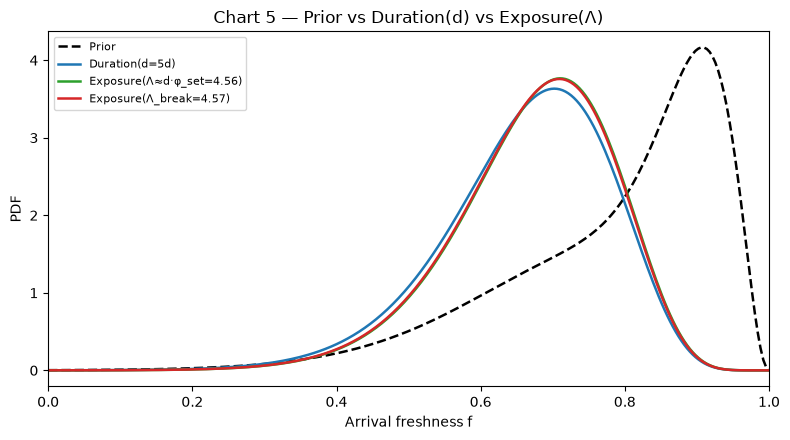

In [6]:
d_typ = 5
lambda_clean = d_typ * PHI_SET
tr_break = next(t for t in SKETCH["tau_bar_traces"] if abs(t["tau_bar"] - 0.5) < 1e-9)
lambda_break = float(tr_break["lambda"])

fig, ax = plt.subplots(figsize=(8, 4.5))
curves = [
    ("prior", {}, "black", "--", "Prior"),
    (f"duration:{d_typ}", {}, "C0", "-", f"Duration(d={d_typ}d)"),
    (f"exposure:{lambda_clean:.3f}", {}, "C2", "-", f"Exposure(Λ≈d·φ_set={lambda_clean:.2f})"),
    (f"exposure:{lambda_break:.3f}", {}, "C3", "-", f"Exposure(Λ_break={lambda_break:.2f})"),
]
for cond, ov, color, ls, label in curves:
    f, pdf, _ = marginal_pdf(cond, overrides=ov)
    ax.plot(f, pdf, color=color, ls=ls, lw=1.8, label=label)

ax.set_xlabel("Arrival freshness f")
ax.set_ylabel("PDF")
ax.set_title("Chart 5 — Prior vs Duration(d) vs Exposure(Λ)")
ax.set_xlim(0, 1)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
